<a href="https://colab.research.google.com/github/GabrielaRguezCampos/GabrielaRguezCampos/blob/main/HEAT_EQUATION_TIME_EVOLUTION_SIMULATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Grid size: 50 x 50
Spatial step dx: 0.0200
Time step dt: 0.000080 (auto-calculated for stability)
Boundary temperature: 100.0°C
Initial interior temperature: 0.0°C
Cooling parameter k: 0.5
Center heat source: 0

Running simulation...
  t = 0.36, Interior avg = 98.2°C, min = 96.5°C, max = 100.0°C
  t = 0.76, Interior avg = 98.3°C, min = 96.6°C, max = 100.0°C
  t = 1.16, Interior avg = 98.3°C, min = 96.6°C, max = 100.0°C
  t = 1.56, Interior avg = 98.3°C, min = 96.6°C, max = 100.0°C
  t = 1.96, Interior avg = 98.3°C, min = 96.6°C, max = 100.0°C

Simulation complete! 52 frames captured.


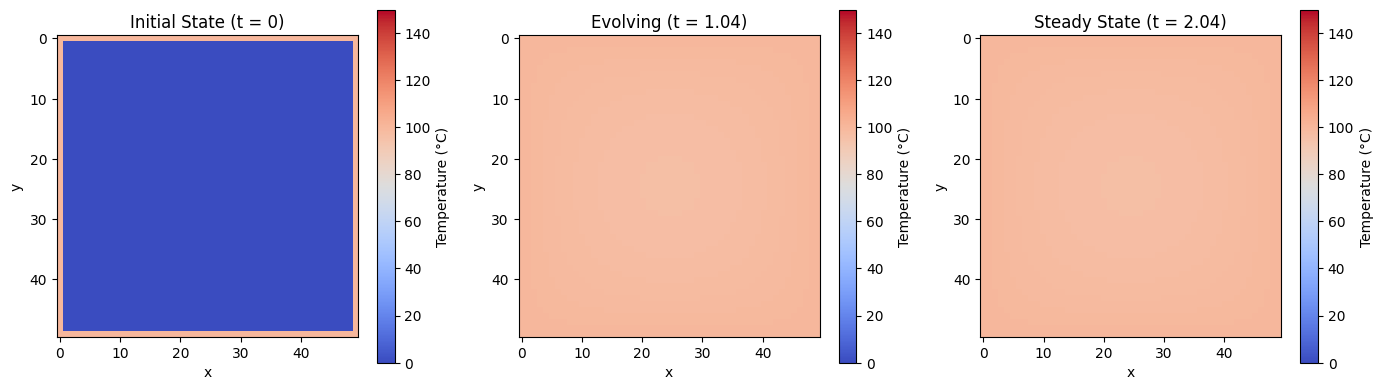


Creating animation (this may take a moment)...


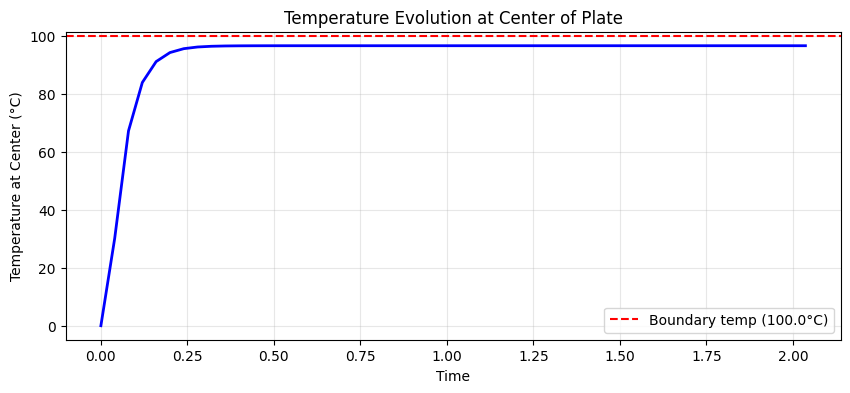


Final center temperature: 96.56°C
Boundary temperature: 100.0°C

With k=0.5 (cooling), the interior settles BELOW the boundary temperature.


In [ ]:
# =============================================================================
# HEAT EQUATION TIME EVOLUTION SIMULATION
# =============================================================================
# This notebook simulates the time-dependent heat equation:
#   ∂u/∂t = ∂²u/∂x² + ∂²u/∂y² - k*u + f(x,y)
#
# Watch how the temperature distribution evolves toward steady state!
# Run this in Google Colab.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

# =============================================================================
# SIMULATION PARAMETERS - PLAY WITH THESE!
# =============================================================================

N = 50                  # Grid size (N x N)
boundary_temp = 100.0   # Temperature at all boundaries (°C)
initial_temp = 0.0      # Initial temperature inside the plate (°C)

k = 0.5                 # Reaction term: k > 0 means cooling to environment
                        #                k < 0 means heat generation
                        #                k = 0 means pure diffusion

source_strength = 0     # Heat source at center (try 50-200 to see effect)

dx = 1.0 / N            # Spatial step

# IMPORTANT: Time step must satisfy stability condition: dt < dx²/4
# We use 20% of the maximum stable dt for safety
dt = 0.2 * (dx**2)      # Automatically calculated stable time step

total_time = 2.0        # Total simulation time (in diffusion time units)
num_frames = 50         # Number of frames in animation
snapshot_interval = total_time / num_frames

# =============================================================================
# INITIALIZE THE GRID
# =============================================================================

def initialize_grid(N, interior_temp, boundary_temp):
    """Create initial temperature distribution with boundary conditions."""
    # Start with interior temperature everywhere
    u = np.ones((N, N)) * interior_temp

    # Set boundary conditions (all edges at boundary_temp)
    u[0, :] = boundary_temp      # Top edge
    u[-1, :] = boundary_temp     # Bottom edge
    u[:, 0] = boundary_temp      # Left edge
    u[:, -1] = boundary_temp     # Right edge

    return u

# Initialize
u = initialize_grid(N, initial_temp, boundary_temp)

# Create source term f(x,y) - heat source at center
f = np.zeros((N, N))
center = N // 2
f[center-1:center+2, center-1:center+2] = source_strength

print(f"Grid size: {N} x {N}")
print(f"Spatial step dx: {dx:.4f}")
print(f"Time step dt: {dt:.6f} (auto-calculated for stability)")
print(f"Boundary temperature: {boundary_temp}°C")
print(f"Initial interior temperature: {initial_temp}°C")
print(f"Cooling parameter k: {k}")
print(f"Center heat source: {source_strength}")

# =============================================================================
# TIME-STEPPING FUNCTION
# =============================================================================

def time_step(u, dt, dx, k, f, boundary_temp):
    """
    Perform one time step of the heat equation using explicit Euler method.

    The discretized equation is:
    u_new[i,j] = u[i,j] + dt * (Laplacian - k*u + f)

    where Laplacian = (u[i+1,j] + u[i-1,j] + u[i,j+1] + u[i,j-1] - 4*u[i,j]) / dx²
    """
    N = u.shape[0]
    u_new = u.copy()

    # Update interior points only (boundaries stay fixed)
    for i in range(1, N-1):
        for j in range(1, N-1):
            # Compute Laplacian (second spatial derivatives)
            laplacian = (u[i+1,j] + u[i-1,j] + u[i,j+1] + u[i,j-1] - 4*u[i,j]) / (dx**2)

            # Heat equation: du/dt = laplacian - k*u + f
            dudt = laplacian - k * u[i,j] + f[i,j]

            # Forward Euler update
            u_new[i,j] = u[i,j] + dt * dudt

    # Boundary conditions remain fixed (Dirichlet)
    u_new[0, :] = boundary_temp
    u_new[-1, :] = boundary_temp
    u_new[:, 0] = boundary_temp
    u_new[:, -1] = boundary_temp

    return u_new

# =============================================================================
# FASTER VERSION USING NUMPY (VECTORIZED)
# =============================================================================

def time_step_fast(u, dt, dx, k, f, boundary_temp):
    """Vectorized version - much faster for large grids!"""
    # Compute Laplacian using array slicing
    laplacian = (
        u[2:, 1:-1] +   # u[i+1, j]
        u[:-2, 1:-1] +  # u[i-1, j]
        u[1:-1, 2:] +   # u[i, j+1]
        u[1:-1, :-2] -  # u[i, j-1]
        4 * u[1:-1, 1:-1]
    ) / (dx**2)

    # Update interior
    u_new = u.copy()
    u_new[1:-1, 1:-1] = u[1:-1, 1:-1] + dt * (
        laplacian - k * u[1:-1, 1:-1] + f[1:-1, 1:-1]
    )

    # Boundary conditions
    u_new[0, :] = boundary_temp
    u_new[-1, :] = boundary_temp
    u_new[:, 0] = boundary_temp
    u_new[:, -1] = boundary_temp

    return u_new

# =============================================================================
# RUN SIMULATION AND STORE SNAPSHOTS
# =============================================================================

print("\nRunning simulation...")

# Reset grid
u = initialize_grid(N, initial_temp, boundary_temp)

# Store snapshots for animation
snapshots = [u.copy()]
times = [0.0]

# Run simulation
t = 0.0
steps_per_snapshot = max(1, int(snapshot_interval / dt))

while t < total_time:
    for _ in range(steps_per_snapshot):
        u = time_step_fast(u, dt, dx, k, f, boundary_temp)
        t += dt

    snapshots.append(u.copy())
    times.append(t)

    # Print progress
    if len(snapshots) % 10 == 0:
        interior = u[1:-1, 1:-1]
        print(f"  t = {t:.2f}, Interior avg = {interior.mean():.1f}°C, "
              f"min = {interior.min():.1f}°C, max = {interior.max():.1f}°C")

print(f"\nSimulation complete! {len(snapshots)} frames captured.")

# =============================================================================
# STATIC PLOT: BEFORE AND AFTER
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Initial state
im0 = axes[0].imshow(snapshots[0], cmap='coolwarm', vmin=0, vmax=max(150, boundary_temp + 20))
axes[0].set_title(f'Initial State (t = 0)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
plt.colorbar(im0, ax=axes[0], label='Temperature (°C)')

# Middle state
mid_idx = len(snapshots) // 2
im1 = axes[1].imshow(snapshots[mid_idx], cmap='coolwarm', vmin=0, vmax=max(150, boundary_temp + 20))
axes[1].set_title(f'Evolving (t = {times[mid_idx]:.2f})')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
plt.colorbar(im1, ax=axes[1], label='Temperature (°C)')

# Final state (steady state)
im2 = axes[2].imshow(snapshots[-1], cmap='coolwarm', vmin=0, vmax=max(150, boundary_temp + 20))
axes[2].set_title(f'Steady State (t = {times[-1]:.2f})')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
plt.colorbar(im2, ax=axes[2], label='Temperature (°C)')

plt.tight_layout()
plt.show()

# =============================================================================
# ANIMATION
# =============================================================================

print("\nCreating animation (this may take a moment)...")

fig, ax = plt.subplots(figsize=(8, 6))

# Set up the plot
vmin = min(initial_temp, 0)
vmax = max(150, boundary_temp + 30)
im = ax.imshow(snapshots[0], cmap='coolwarm', vmin=vmin, vmax=vmax, animated=True)
cbar = plt.colorbar(im, ax=ax, label='Temperature (°C)')
title = ax.set_title('t = 0.00')
ax.set_xlabel('x')
ax.set_ylabel('y')

def animate(frame):
    """Update function for animation."""
    im.set_array(snapshots[frame])
    title.set_text(f't = {times[frame]:.2f}  |  Interior avg: {snapshots[frame][1:-1,1:-1].mean():.1f}°C')
    return [im, title]

# Create animation
anim = animation.FuncAnimation(
    fig,
    animate,
    frames=len(snapshots),
    interval=100,  # milliseconds between frames
    blit=True
)

# Display in Colab
plt.close()  # Prevent static display
HTML(anim.to_jshtml())

# =============================================================================
# ALTERNATIVE: SAVE AS GIF (uncomment if you want to save)
# =============================================================================

# anim.save('heat_evolution.gif', writer='pillow', fps=10)
# print("Animation saved as 'heat_evolution.gif'")

# =============================================================================
# PLOT: TEMPERATURE EVOLUTION AT CENTER POINT
# =============================================================================

# Extract center temperature over time
center_temps = [snap[N//2, N//2] for snap in snapshots]

plt.figure(figsize=(10, 4))
plt.plot(times, center_temps, 'b-', linewidth=2)
plt.axhline(y=boundary_temp, color='r', linestyle='--', label=f'Boundary temp ({boundary_temp}°C)')
plt.xlabel('Time')
plt.ylabel('Temperature at Center (°C)')
plt.title('Temperature Evolution at Center of Plate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nFinal center temperature: {center_temps[-1]:.2f}°C")
print(f"Boundary temperature: {boundary_temp}°C")

if k > 0:
    print(f"\nWith k={k} (cooling), the interior settles BELOW the boundary temperature.")
elif k < 0:
    print(f"\nWith k={k} (heating), the interior settles ABOVE the boundary temperature.")
else:
    print(f"\nWith k=0 (pure diffusion), the interior approaches the boundary temperature.")